This notebook introduces creating Fields and operator objects in Dedalus. Dedalus will use these fields and operator objects to solve a symbolic algebra system, which represents mathematical expressions and PDEs.

# Fields
After create basis of problem, we instantiate field objetcs by using 'dist.Field' method based on defined basis. For example:

In [ ]:
# for scalar fields
f = dist.Field(name='f', bases=(xbasis, zbasis)) # maybe use 'ScalarField' instead of 'Field'
# create scalar field f on both x and z dimensions

# for vector or tensor fields
u = dist.VectorField(coords, name='u', bases=xbasis) # create vector u on only x dimension
s = dist.TensorField(coords, name='u', bases=zbasis) # create tensor s on only z dimension

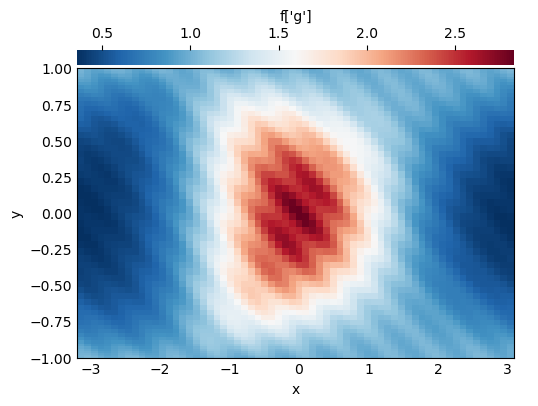

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from dedalus.extras.plot_tools import plot_bot_2d
figkw = {'figsize':(6,4), 'dpi':100}

coords = d3.CartesianCoordinates('x', 'y')
dist = d3.Distributor(coords, dtype=np.float64)

xbasis = d3.RealFourier(coords['x'], 64, bounds=(-np.pi, np.pi), dealias=3/2)
ybasis = d3.Chebyshev(coords['y'], 64, bounds=(-1, 1), dealias=3/2)

f = dist.Field(name='f', bases=(xbasis, ybasis))

u = dist.VectorField(coords, name='u', bases=xbasis)

f.layout.grid_space

x = dist.local_grid(xbasis)
y = dist.local_grid(ybasis)
f['g'] = np.exp((1-y**2)*np.cos(x+np.cos(x)*y**2)) * (1 + 0.05*np.cos(10*(x+2*y)))

# Plot grid values
plot_bot_2d(f, figkw=figkw, title="f['g']")
plt.savefig("example_defineField.png", dpi=200)